In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [77]:

df=pd.read_csv('Dataset/pizza_sales.csv')
df.head()

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,1/1/2015,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,1/1/2015,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,1/1/2015,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,1/1/2015,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,1/1/2015,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


In [78]:
X = df[['quantity', 'unit_price', 'total_price']]

In [79]:
scaler = StandardScaler()

X_scale = scaler.fit_transform(X)

In [80]:

k_range = range(1, 21)
error_rate = []



for i in k_range:
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(X_scale)
    error_rate.append(kmeans.inertia_)

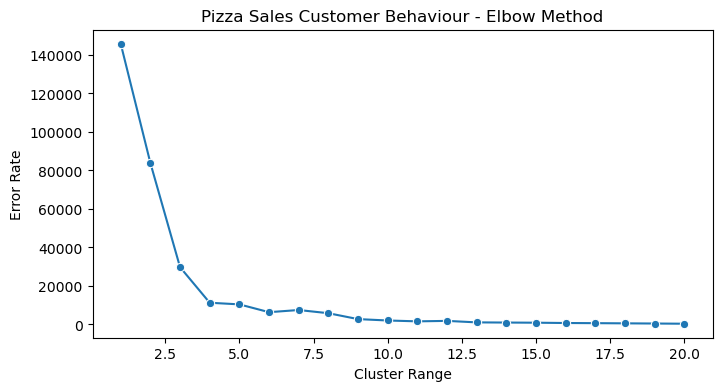

In [81]:

plt.figure(figsize=(8, 4))
sns.lineplot(x= k_range, y=error_rate, marker='o')

plt.xlabel("Cluster Range")
plt.ylabel("Error Rate")

plt.title("Pizza Sales Customer Behaviour - Elbow Method")

plt.show()

In [82]:
k = 3
model = KMeans(n_clusters=k)
cluster = model.fit_predict(X_scale)

In [83]:

df['cluster']=cluster

In [84]:
sc = silhouette_score(X_scale, cluster)


In [85]:
print(f'Silhouette Score: {sc * 100:.2f}%')

Silhouette Score: 64.32%


In [86]:
import plotly.express as px

In [87]:
 px.scatter_3d(
    df,
    x='unit_price',
    y='total_price',
    z='quantity',
    color='cluster'
 )

In [88]:
from sklearn.decomposition import PCA


In [89]:
feature=['quantity', 'unit_price', 'total_price']

In [90]:
pca = PCA(n_components=len(feature))

In [91]:
x_pca = pca.fit_transform(X_scale)

In [92]:
loadings = pd.DataFrame(
    pca.components_,
    columns=feature,
    index=[f'PC{i+1}' for i in range(len(feature))]
)

loadings

,quantity,unit_price,total_price
PC1,0.386953,0.593218,0.705946
PC2,0.839152,-0.543890,-0.002927
PC3,-0.382220,-0.593529,0.708260


In [95]:
#pc1->unit_price
#pc2->quantity,total_price

Text(0.5, 1.0, 'PCA1 AND PCA2')

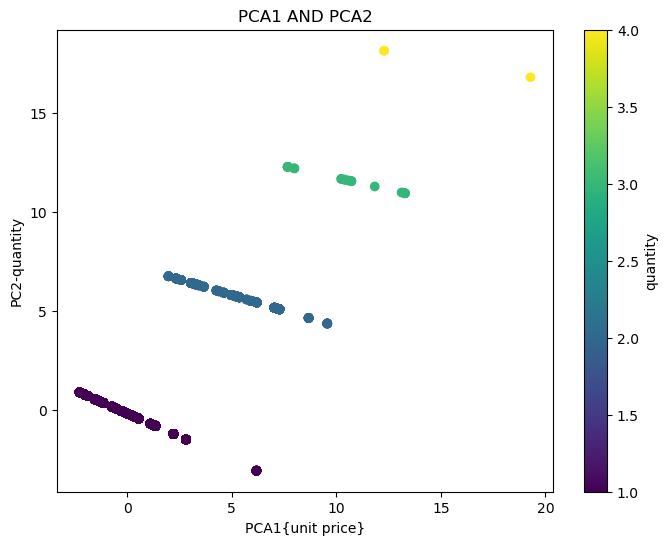

In [99]:
plt.figure(figsize=(8, 6))
col='quantity'

scatter=plt.scatter(
    x=x_pca[:, 0],
    y=x_pca [:, 1],
    c=df[col]
)
plt.colorbar(scatter,label=col)
plt.xlabel('PCA1{unit price}')
plt.ylabel(f'PC2-{col}')
plt.title('PCA1 AND PCA2')